In [1]:
import pandas as pd

# Load CSV file
Dataset_Train = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Train_Final.csv')
Dataset_Test = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Test_Final.csv')

# Display first 5 rows
Dataset_Train.head()
Dataset_Test.head()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier
0,Male,No,31,Yes,Entertainment,0.0,Low,5.0,Cat_6,D,No_Low,False
1,Female,No,46,Yes,Entertainment,8.0,Low,2.0,Cat_6,D,No_Low,False
2,Male,Yes,60,Yes,Artist,0.0,Average,4.0,Cat_6,C,Yes_Average,False
3,Female,No,41,Yes,Artist,0.0,Low,1.0,Cat_6,A,No_Low,False
4,Female,Yes,52,Yes,Artist,6.0,Low,2.0,Cat_6,A,Yes_Low,False


In [2]:
import numpy as np

Dataset_Train['Segmentation_Combined'] = np.where(
    Dataset_Train['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Train['Segmentation']
)

Dataset_Test['Segmentation_Combined'] = np.where(
    Dataset_Test['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Test['Segmentation']
)
Dataset_Train.head()
Dataset_Test.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier,Segmentation_Combined
0,Male,No,31,Yes,Entertainment,0.0,Low,5.0,Cat_6,D,No_Low,False,D
1,Female,No,46,Yes,Entertainment,8.0,Low,2.0,Cat_6,D,No_Low,False,D
2,Male,Yes,60,Yes,Artist,0.0,Average,4.0,Cat_6,C,Yes_Average,False,ABC
3,Female,No,41,Yes,Artist,0.0,Low,1.0,Cat_6,A,No_Low,False,ABC
4,Female,Yes,52,Yes,Artist,6.0,Low,2.0,Cat_6,A,Yes_Low,False,ABC


In [3]:
#remove outlier
Dataset_Train.drop("Multivariate_Outlier", axis=1, inplace=True)
Dataset_Test.drop("Multivariate_Outlier", axis=1, inplace=True)
#remove Marital_Spending_Group
#Dataset_Train.drop("Marital_Spending_Group", axis=1, inplace=True)
#Dataset_Test.drop("Marital_Spending_Group", axis=1, inplace=True)
#remove gender
Dataset_Train = Dataset_Train.drop('Gender', axis=1)
Dataset_Test = Dataset_Test.drop('Gender', axis=1)
#remove gender
Dataset_Train = Dataset_Train.drop('Segmentation', axis=1)
Dataset_Test = Dataset_Test.drop('Segmentation', axis=1)
#remove Var_1
#Dataset_Train = Dataset_Train.drop('Var_1', axis=1)
#Dataset_Test = Dataset_Test.drop('Var_1', axis=1)
#remove Ever_Married
Dataset_Train.drop("Ever_Married", axis=1, inplace=True)
Dataset_Test.drop("Ever_Married", axis=1, inplace=True)
#remove Spending_Score
Dataset_Train.drop("Spending_Score", axis=1, inplace=True)
Dataset_Test.drop("Spending_Score", axis=1, inplace=True)

In [4]:
Dataset_Train.head()

,Age,Graduated,Profession,Work_Experience,Family_Size,Var_1,Marital_Spending_Group,Segmentation_Combined
0,46,No,Executive,0.0,2.0,Cat_6,Yes_High,ABC
1,37,Yes,Artist,1.0,2.0,Cat_7,Yes_High,ABC
2,27,Yes,Engineer,1.0,2.0,Cat_6,Yes_Low,D
3,18,No,Healthcare,2.0,5.0,Cat_6,No_Low,D
4,28,Yes,Marketing,12.0,1.0,Cat_6,No_Low,ABC


reducing the categoties of  profession variable

In [5]:
# Convert object columns to category and bool columns to numeric (0/1) in both datasets
for df in [Dataset_Train, Dataset_Test]:
    obj_cols = df.select_dtypes(include='object').columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[obj_cols] = df[obj_cols].astype('category')
    df[bool_cols] = df[bool_cols].astype('int')

Check for class balance in the response

🔹 Class Counts:
Segmentation_Combined
ABC    6119
D      2406
Name: count, dtype: int64

🔹 Class Percentages:
Segmentation_Combined
ABC    71.78
D      28.22
Name: proportion, dtype: float64


C:\Users\Ashani Madushani\AppData\Local\Temp\ipykernel_4612\3910772525.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')


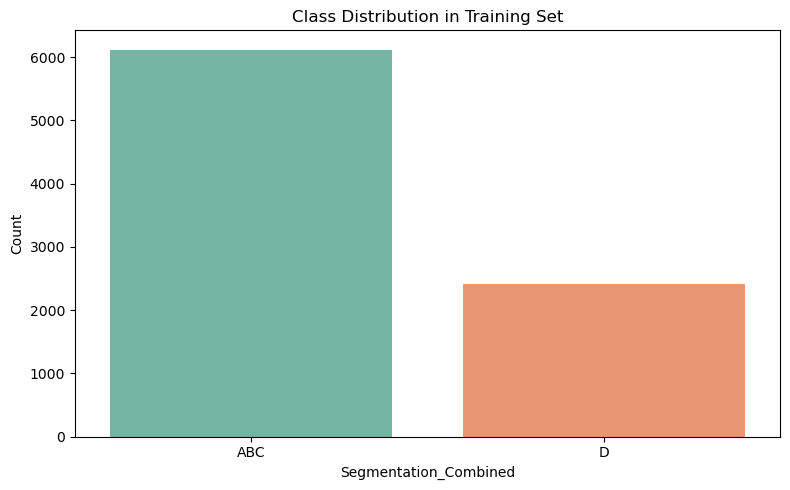

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of instances in each class
class_counts = Dataset_Train['Segmentation_Combined'].value_counts()
class_percentages = Dataset_Train['Segmentation_Combined'].value_counts(normalize=True) * 100

# Display results
print("🔹 Class Counts:")
print(class_counts)
print("\n🔹 Class Percentages:")
print(class_percentages.round(2))

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')
plt.title("Class Distribution in Training Set")
plt.xlabel("Segmentation_Combined")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


applying SMOTE to balance

🔹 Train Accuracy: 0.9637536656891496
🔹 Test Accuracy: 0.7532833020637899

🔹 Classification Report (Test):

              precision    recall  f1-score   support

         ABC       0.80      0.87      0.83      1530
           D       0.58      0.46      0.51       602

    accuracy                           0.75      2132
   macro avg       0.69      0.66      0.67      2132
weighted avg       0.74      0.75      0.74      2132



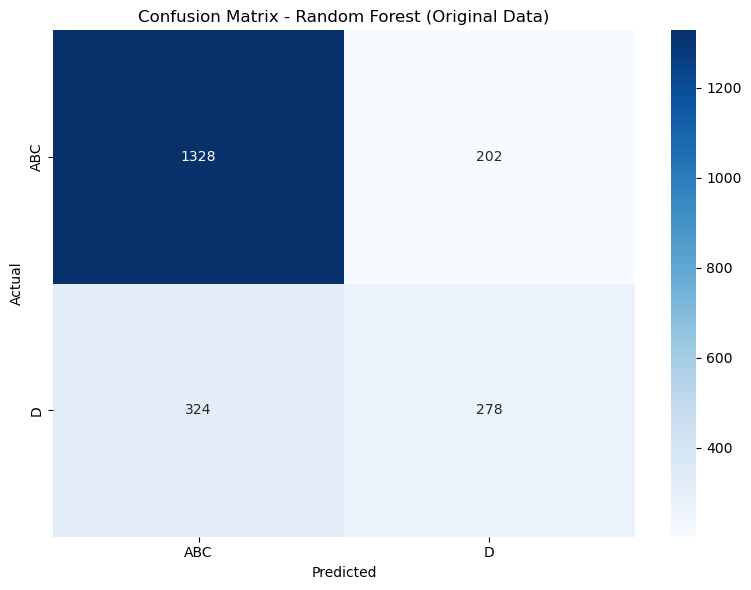

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define target and features
target_col = 'Segmentation_Combined'
X_train = Dataset_Train.drop(columns=[target_col])
y_train = Dataset_Train[target_col]
X_test = Dataset_Test.drop(columns=[target_col])
y_test = Dataset_Test[target_col]

# 2. Identify feature types
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# 4. Process data WITHOUT SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Train Random Forest on original data
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # Handles imbalance by adjusting weights
)
rf_model.fit(X_train_processed, y_train)

# 6. Predictions
y_train_pred = rf_model.predict(X_train_processed)
y_test_pred = rf_model.predict(X_test_processed)

# 7. Evaluation
print("🔹 Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("🔹 Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Confusion Matrix - Random Forest (Original Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Assuming your data is already loaded in Dataset_Train
X = Dataset_Train.drop(columns=['Segmentation_Combined'])
y = Dataset_Train['Segmentation_Combined']

# Split train/test if needed (optional)
# X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 1. Identify column types
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Preprocessor pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# 3. Fit preprocessor and transform features
X_processed = preprocessor.fit_transform(X)

# 4. Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_processed, y)

# 5. Optional: Check new class distribution
print("✅ Class distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Now you can use X_resampled and y_resampled to train your models


✅ Class distribution after SMOTE:
Segmentation_Combined
ABC    6119
D      6119
Name: count, dtype: int64


🔹 Train Accuracy: 0.9749959143650924
🔹 Test Accuracy : 0.7424953095684803

🔹 Classification Report (Test):

              precision    recall  f1-score   support

         ABC       0.81      0.84      0.82      1530
           D       0.55      0.49      0.52       602

    accuracy                           0.74      2132
   macro avg       0.68      0.67      0.67      2132
weighted avg       0.74      0.74      0.74      2132



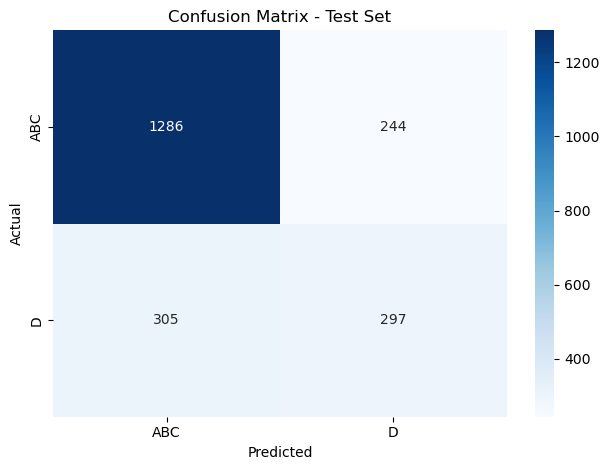

In [9]:
#random forest
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Step 1: Define target and features
target_col = 'Segmentation_Combined'
X_train_raw = Dataset_Train.drop(columns=[target_col])
y_train_raw = Dataset_Train[target_col]
X_test = Dataset_Test.drop(columns=[target_col])
y_test = Dataset_Test[target_col]

# 📌 Step 2: Identify feature types
numeric_cols = X_train_raw.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# 📌 Step 3: Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# 📌 Step 4: Preprocess training data and apply SMOTE
X_train_processed = preprocessor.fit_transform(X_train_raw)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train_raw)

# 📌 Step 5: Preprocess test data
X_test_processed = preprocessor.transform(X_test)

# 📌 Step 6: Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# 📌 Step 7: Predictions
y_train_pred = rf_model.predict(X_train_resampled)
y_test_pred = rf_model.predict(X_test_processed)

# 📌 Step 8: Evaluation
print("🔹 Train Accuracy:", accuracy_score(y_train_resampled, y_train_pred))
print("🔹 Test Accuracy :", accuracy_score(y_test, y_test_pred))

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

# Optional: Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
✅ Train Accuracy: 0.9460696192188266
✅ Test Accuracy : 0.7523452157598499

🔹 Classification Report (Test):

              precision    recall  f1-score   support

         ABC       0.81      0.85      0.83      1530
           D       0.57      0.51      0.54       602

    accuracy                           0.75      2132
   macro avg       0.69      0.68      0.68      2132
weighted avg       0.75      0.75      0.75      2132



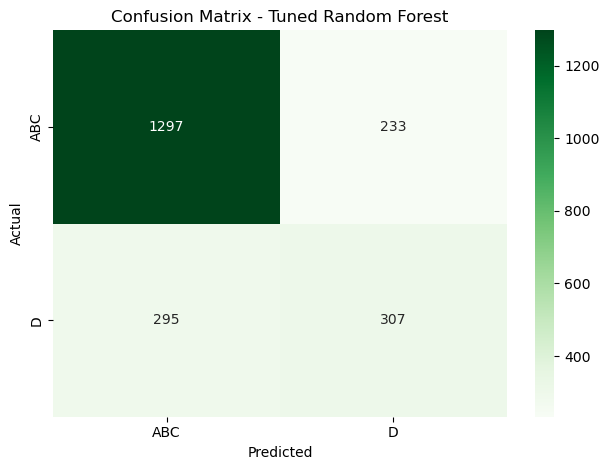

In [10]:
#Hyper parameter tune and fitting random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# Step 2: Preprocess training data
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test)

# Step 3: Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train_raw)

# Step 4: Define model and parameter grid
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Step 5: GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train_resampled, y_train_resampled)

# Step 6: Best estimator
best_rf = grid_search.best_estimator_

# Step 7: Evaluation
y_train_pred = best_rf.predict(X_train_resampled)
y_test_pred = best_rf.predict(X_test_processed)

print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Train Accuracy:", accuracy_score(y_train_resampled, y_train_pred))
print("✅ Test Accuracy :", accuracy_score(y_test, y_test_pred))

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

# Step 8: Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


✅ Train Accuracy: 0.964574780058651
✅ Test Accuracy : 0.7734521575984991

🔹 Classification Report (Test Data):
              precision    recall  f1-score   support

         ABC       0.81      0.89      0.85      1530
           D       0.63      0.48      0.54       602

    accuracy                           0.77      2132
   macro avg       0.72      0.68      0.70      2132
weighted avg       0.76      0.77      0.76      2132



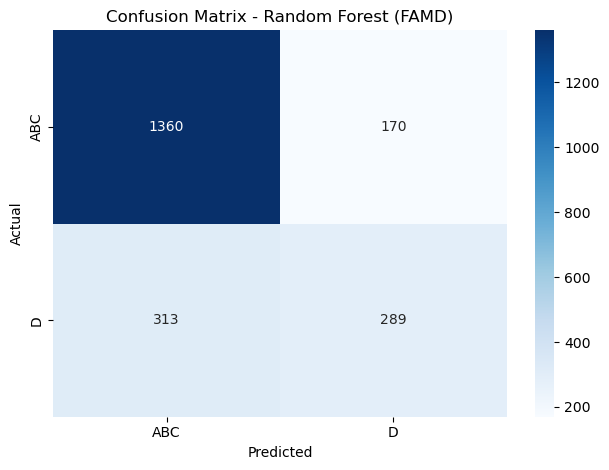

In [11]:
#Applying FAMD and reducing predictors, fit the random forest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import prince  # for FAMD

# ✅ 1. Prepare Data
X_train = Dataset_Train.drop(columns=['Segmentation_Combined'])
y_train = Dataset_Train['Segmentation_Combined']

X_test = Dataset_Test.drop(columns=['Segmentation_Combined'])
y_test = Dataset_Test['Segmentation_Combined']

# ✅ 2. Combine Train + Test for consistent FAMD transformation
X_all = pd.concat([X_train, X_test], axis=0)
X_all.reset_index(drop=True, inplace=True)

# ✅ 3. Apply FAMD
famd = prince.FAMD(n_components=20, random_state=42)
famd = famd.fit(X_all)

# ✅ 4. Transform train and test separately
X_train_famd = famd.transform(X_train)
X_test_famd = famd.transform(X_test)

# ✅ 5. Fit Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_famd, y_train)

# ✅ 6. Predict
y_train_pred = rf.predict(X_train_famd)
y_test_pred = rf.predict(X_test_famd)

# ✅ 7. Evaluate
print("✅ Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("✅ Test Accuracy :", accuracy_score(y_test, y_test_pred))

print("\n🔹 Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# ✅ 8. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=rf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Confusion Matrix - Random Forest (FAMD)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd

# Load CSV file
Dataset_Train = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Train_Final.csv')
Dataset_Test = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Test_Final.csv')

# Display first 5 rows
Dataset_Train.head()
Dataset_Test.head()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier
0,Female,Yes,39,No,Engineer,0.0,Low,2.0,Cat_6,A,Yes_Low,False
1,Male,No,28,Yes,Healthcare,1.0,Low,4.0,Cat_6,D,No_Low,False
2,Male,No,30,No,Healthcare,1.0,Low,4.0,Cat_2,A,No_Low,False
3,Male,Yes,62,Yes,Entertainment,1.0,Average,3.0,Cat_6,C,Yes_Average,False
4,Male,Yes,45,Yes,Artist,4.0,Average,4.0,Cat_6,B,Yes_Average,False


In [13]:
#remove outlier
Dataset_Train.drop("Multivariate_Outlier", axis=1, inplace=True)
Dataset_Test.drop("Multivariate_Outlier", axis=1, inplace=True)
#remove Marital_Spending_Group
Dataset_Train.drop("Marital_Spending_Group", axis=1, inplace=True)
Dataset_Test.drop("Marital_Spending_Group", axis=1, inplace=True)
#remove gender
Dataset_Train = Dataset_Train.drop('Gender', axis=1)
Dataset_Test = Dataset_Test.drop('Gender', axis=1)
#remove gender
#Dataset_Train = Dataset_Train.drop('Segmentation', axis=1)
#Dataset_Test = Dataset_Test.drop('Segmentation', axis=1)
#remove Var_1
#Dataset_Train = Dataset_Train.drop('Var_1', axis=1)
#Dataset_Test = Dataset_Test.drop('Var_1', axis=1)
#remove Ever_Married
#Dataset_Train.drop("Ever_Married", axis=1, inplace=True)
#Dataset_Test.drop("Ever_Married", axis=1, inplace=True)
#remove Spending_Score
#Dataset_Train.drop("Spending_Score", axis=1, inplace=True)
#Dataset_Test.drop("Spending_Score", axis=1, inplace=True)

In [14]:
# Convert object columns to category and bool columns to numeric (0/1) in both datasets
for df in [Dataset_Train, Dataset_Test]:
    obj_cols = df.select_dtypes(include='object').columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[obj_cols] = df[obj_cols].astype('category')
    df[bool_cols] = df[bool_cols].astype('int')

🔹 Train Accuracy: 0.907683284457478
🔹 Test Accuracy: 0.398686679174484

🔹 Classification Report (Test):

              precision    recall  f1-score   support

           A       0.33      0.35      0.34       563
           B       0.29      0.30      0.29       480
           C       0.40      0.37      0.38       487
           D       0.55      0.55      0.55       602

    accuracy                           0.40      2132
   macro avg       0.39      0.39      0.39      2132
weighted avg       0.40      0.40      0.40      2132



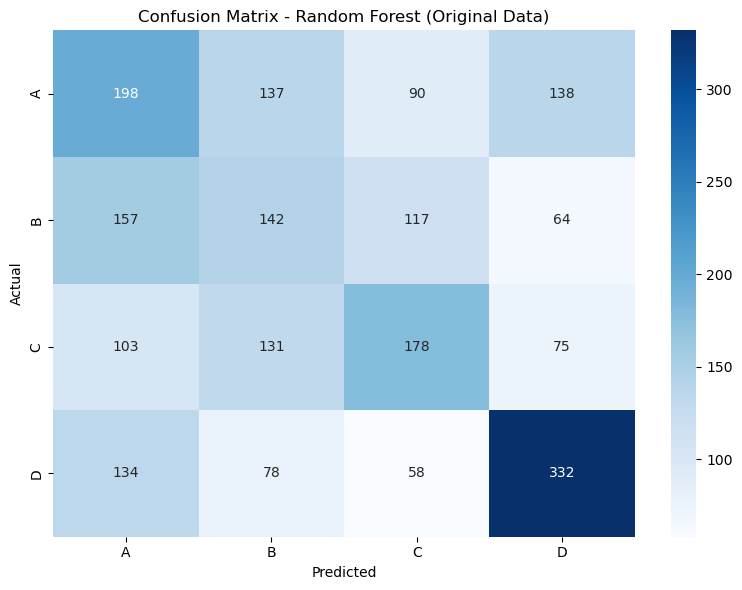

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define target and features
target_col = 'Segmentation'
X_train = Dataset_Train.drop(columns=[target_col])
y_train = Dataset_Train[target_col]
X_test = Dataset_Test.drop(columns=[target_col])
y_test = Dataset_Test[target_col]

# 2. Identify feature types
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# 4. Process data WITHOUT SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Train Random Forest on original data
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # Handles imbalance by adjusting weights
)
rf_model.fit(X_train_processed, y_train)

# 6. Predictions
y_train_pred = rf_model.predict(X_train_processed)
y_test_pred = rf_model.predict(X_test_processed)

# 7. Evaluation
print("🔹 Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("🔹 Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\n🔹 Classification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Confusion Matrix - Random Forest (Original Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()